In [1]:
# including libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# data ingestion
customer_data=pd.read_csv("Ecommerce_Customers.csv")

In [3]:

# data inspection from here on


In [4]:
customer_data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
customer_data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


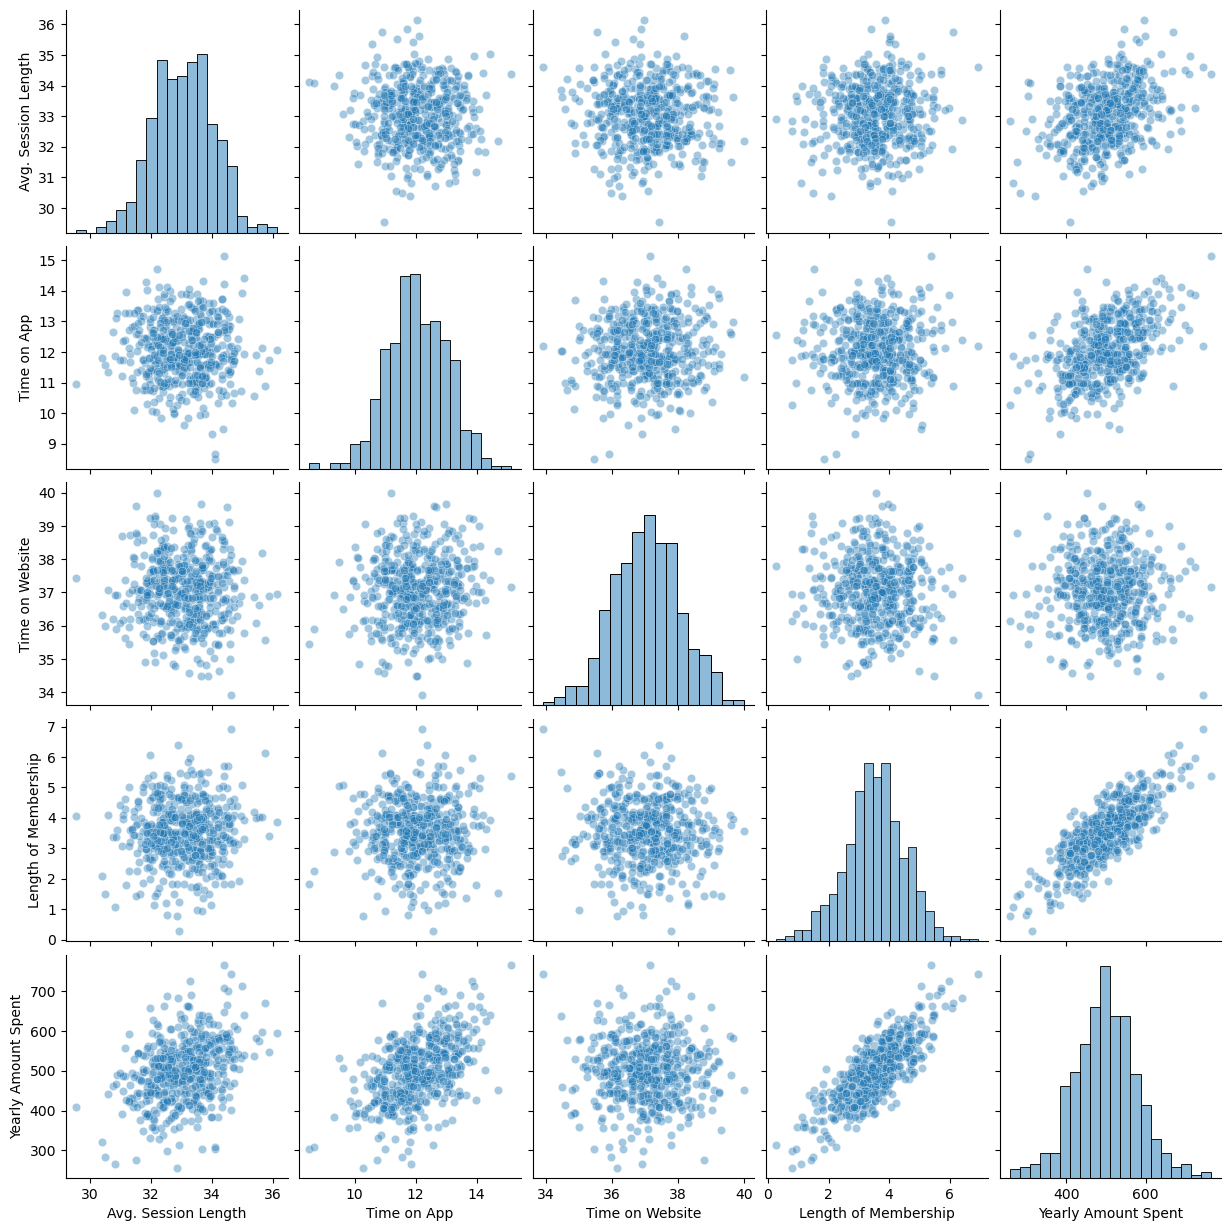

In [6]:
sns.pairplot(data=customer_data, plot_kws={"alpha":0.4}, diag_kws={"alpha":0.5})

Text(0.5, 1.0, 'Linear Regression on Yearly Amount Spent vs Membership Length')

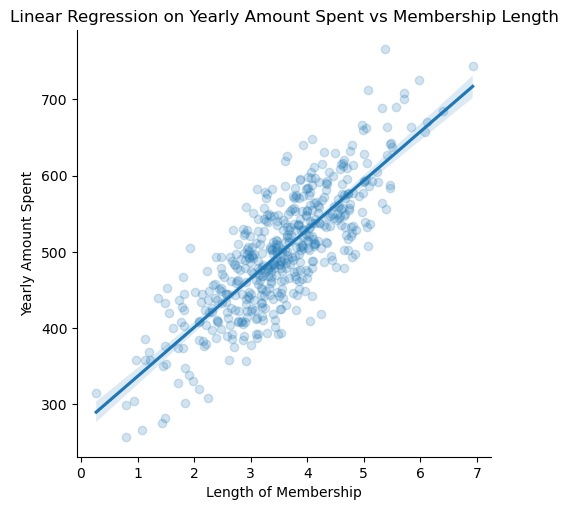

In [7]:
sns.lmplot(x="Length of Membership", y="Yearly Amount Spent", data=customer_data, scatter_kws={"alpha":0.2})
plt.title("Linear Regression on Yearly Amount Spent vs Membership Length")

In [8]:
# feature selection
from sklearn.model_selection import train_test_split

x =customer_data[["Avg. Session Length","Time on App","Time on Website","Length of Membership"]]
y =customer_data["Yearly Amount Spent"]

In [9]:
# train test split (80/20)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
# Model initialization and training
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [11]:
# Model training
prediction=model.predict(x_test)

In [12]:

# model analysis and evaluation from here on


Text(0.5, 1.0, 'Scatterplot of Predicted points vs Yearly Amount Spent')

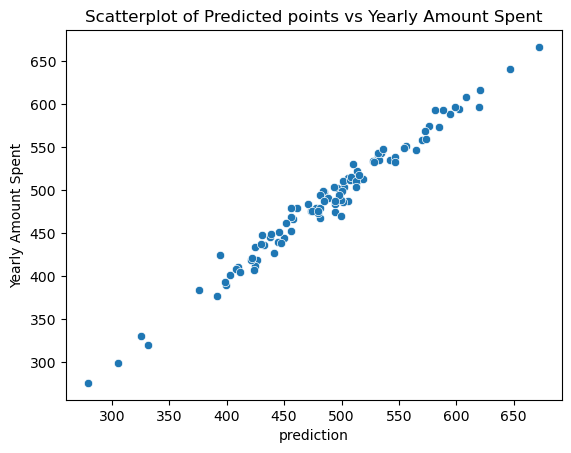

In [13]:
sns.scatterplot(y=y_test, x=prediction)
plt.xlabel("prediction")
plt.ylabel("Yearly Amount Spent")
plt.title("Scatterplot of Predicted points vs Yearly Amount Spent")

In [14]:
# R^2
model.score(x_test,y_test)

0.9778130629248283

In [15]:
# coefficients ["Avg. Session Length","Time on App","Time on Website","Length of Membership"]
model.coef_

array([25.59625911, 38.78534599,  0.31038592, 61.89682859])

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Mean Absolute Error: ",mean_absolute_error(y_test, prediction))
print("Mean Squared Error: ",mean_squared_error(y_test, prediction))
print("Root Mean Squared Error: ",math.sqrt(mean_squared_error(y_test, prediction)))

Mean Absolute Error:  8.5584418874381
Mean Squared Error:  109.86374115216144
Root Mean Squared Error:  10.481590583120552


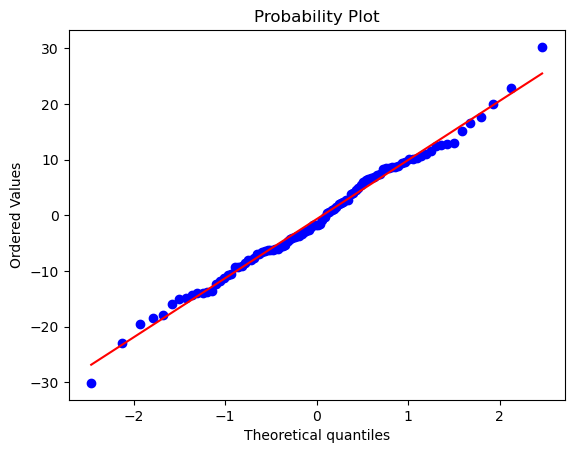

In [17]:
import pylab 
import scipy.stats as stats

residuals = y_test-prediction
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()